I am following along with this [written content](https://www.hackersrealm.net/post/iris-dataset-analysis-using-python)

And here is the [Kaggle data set](https://www.kaggle.com/datasets/uciml/iris)

# Dataset Information

The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other.

The columns in this dataset are:

- Id
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm
- Species


# Importing modules

In [1]:
import pandas as pd #pandas - used to perform data manipulation and analysis
import numpy as np #numpy - used to perform a wide variety of mathematical operations on arrays
import matplotlib.pyplot as plt #matplotlib - used for data visualization and graphical plotting
import seaborn as sns #seaborn - built on top of matplotlib with similar functionalities
import warnings #warnings - to manipulate warnings details
warnings.filterwarnings('ignore')  #filterwarnings('ignore') is to ignore the warnings thrown by the modules (gives clean results)

# Loading the Dataset

In [2]:
df = pd.read_csv('Iris.csv')
df.head() #displays the 5 first rows from the dataframe

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.drop(columns = ['Id'])   #deleting id column cuz it has no value here
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.describe() ## display stats about data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.info() #get the datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


 ### It means All the input attributes(0-3) are in float and the output attribute(4) is in object

In [6]:
df['Species'].value_counts() ## display nummber of samples on each class for Species column

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Preprocessing the dataset

In [7]:
df.isnull().sum() #checking for null values

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

 - So no NULL value present in the dataset. 

 - If any NULL values are present, we have to fill all the NULL values before proceeding to model training.

# Exploratory Data Analysis
In Exploratory Data Analysis(EDA), we will visualize the data with different kinds of plots for inference. It is helpful to find some patterns (or) relations within the data

<Axes: >

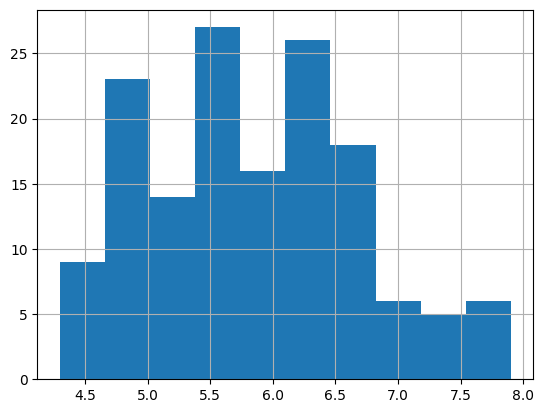

In [8]:
df['SepalLengthCm'].hist() 
#hist shows the histograms
#histogram for Sepal Length

<Axes: >

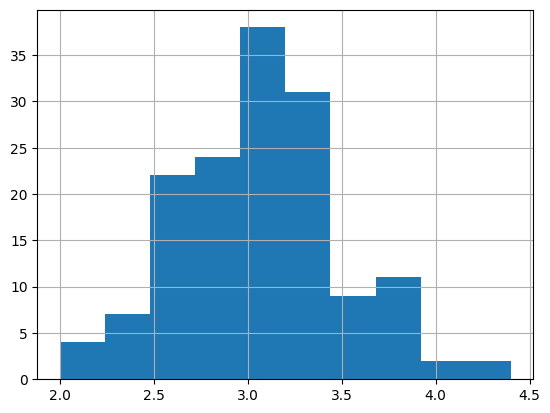

In [9]:
df['SepalWidthCm'].hist() 
#histogram for Sepal Width

### Sepal Length and Sepal Width forming a normal distribution or *Gaussian distribution*

<Axes: >

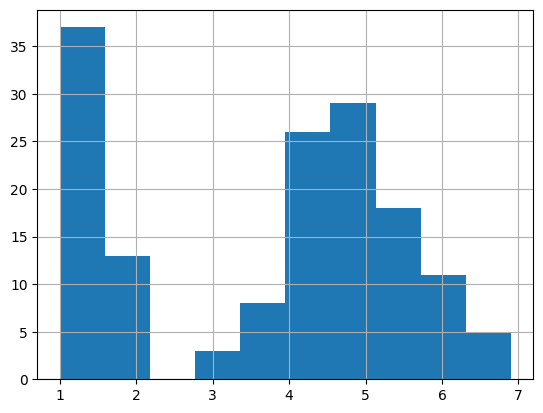

In [10]:
df['PetalLengthCm'].hist()
#histogram for Petal Length

<Axes: >

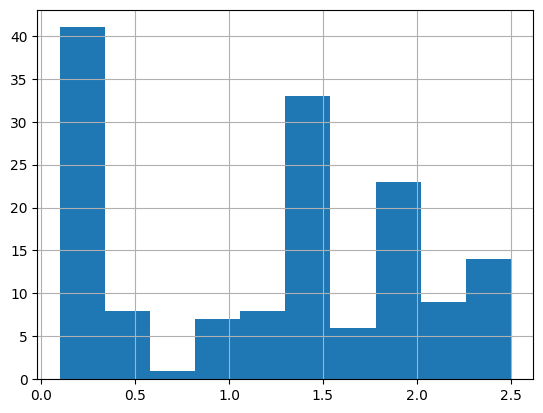

In [11]:
df['PetalWidthCm'].hist()
#histogram for Petal Width

### Petal Length and Petal Width has no normal distribution, rather have two separate bells, it's due to the measurements of different species

# Let's create some scatter plots for inference
## Scatter Plot on Sepal Length and Sepal Width

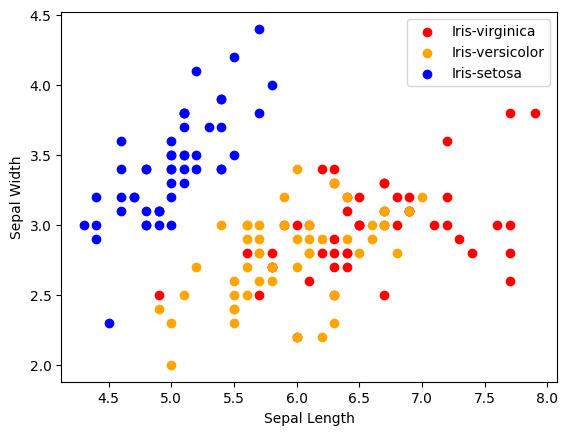

In [12]:
# creating list of colors and class labels
colors = ['red', 'orange', 'blue']
species = ['Iris-virginica', 'Iris-versicolor', 'Iris-setosa']

for i in range(3):
    # filter data on each class
    x = df[df['Species'] == species[i]]  #filters samples for each class label
    # plot the scatter plot
    plt.scatter(x['SepalLengthCm'], x['SepalWidthCm'], c = colors[i], label=species[i])
    #generates a scatterplot for the data
    
plt.xlabel("Sepal Length") #label for x-axis
plt.ylabel("Sepal Width")  #label for y-axis
plt.legend() #display the legend for the plot

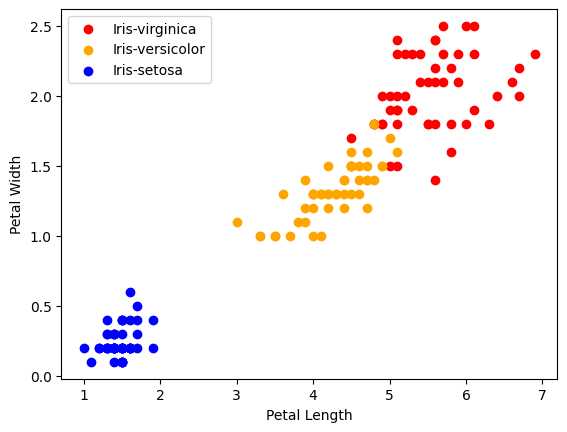

In [13]:
for i in range(3):
    # filter data on each class
    x = df[df['Species'] == species[i]]
    # plot the scatter plot
    plt.scatter(x['PetalLengthCm'], x['PetalWidthCm'], c = colors[i], label=species[i])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()

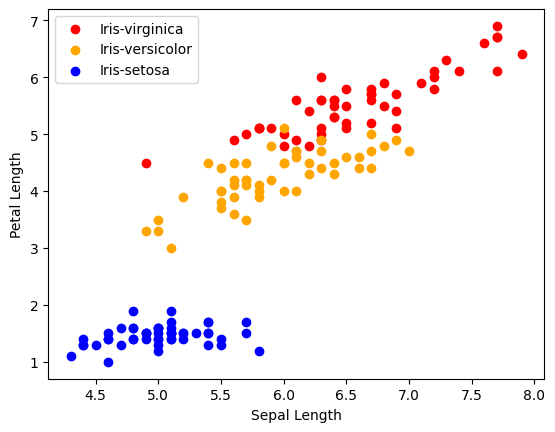

In [14]:
for i in range(3):
    # filter data on each class
    x = df[df['Species'] == species[i]]
    # plot the scatter plot
    plt.scatter(x['SepalLengthCm'], x['PetalLengthCm'], c = colors[i], label=species[i])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()

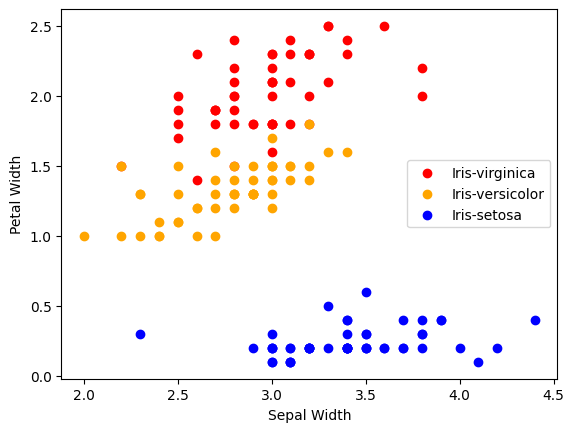

In [15]:
for i in range(3):
    # filter data on each class
    x = df[df['Species'] == species[i]]
    # plot the scatter plot
    plt.scatter(x['SepalWidthCm'], x['PetalWidthCm'], c = colors[i], label=species[i])
plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.legend()

# Correlation Matrix
A correlation matrix is a table showing correlation coefficients between variables. Each cell in the table shows the correlation between two variables. The value is in the range of -1 to 1. If two variables have high correlation, we can neglect one variable from those two.

In [16]:
df.select_dtypes(include="number").corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


## note

### using df.corr() to displaying the correlation matrix cant get numeric values automatically 
So i followed this **[thread](https://stackoverflow.com/questions/74305444/error-while-trying-to-run-corr-in-python-with-pandas-module)** in stack overflow and they told to use **df.select_dtypes(include="number").corr()**
and it worked for me here

### Plotting the heatmap

<Axes: >

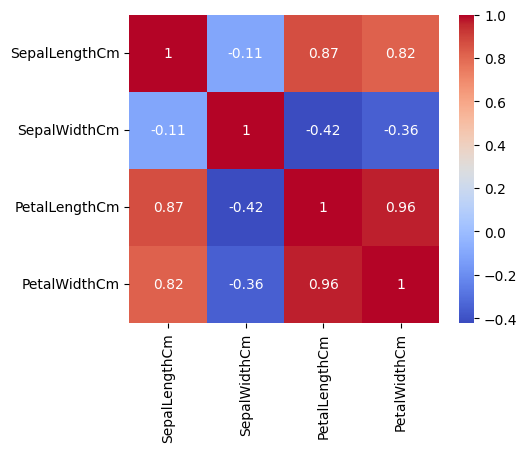

In [17]:
corr = df.select_dtypes(include="number").corr()
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, ax=ax, cmap = 'coolwarm')


- Petal length and petal width have high positive correlation of 0.96

- If petal length value increases, petal width also increases

- Sepal length have high positive correlation with petal length and petal width

- Sepal width have negative correlation with petal length and petal width

# Label Encoder
In machine learning, we usually deal with datasets which contains multiple labels in one or more than one columns. These labels can be in the form of words or numbers. Label Encoding refers to converting the labels into numeric form so as to convert it into the machine-readable form.

It converst the catagorical colums with strings to numeric ( *here for the **species**  column*)

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# transform the string labels to integer
df['Species'] = le.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# preprocessing has been done, let's perform the model training and testing

### Model Training and Testing



We will use the same dataset for train and test 
It will be 
- train - 70%
- test - 30%

In [19]:
from sklearn.model_selection import train_test_split

# input data
X = df.drop(columns=['Species'])

# output data
Y = df['Species']

# split the data for train and test
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30)

**X** - contains input attributes

**Y** - contains the output attribute

**train_test_split()** - splits the data for training and testing (here we are splitting 70% data for training and 30% for testing)



# Let's import some models
## Here we will use the ***logistic regression***

In [20]:
# importing logistic regression 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

### model training

***fit()*** - used for training the model with the data
- This method trains the model by finding the best parameters (weights and bias) that minimize the error in predicting y_train from x_train.
- it will be like **model.fit(x_train, y_train)**
- **x_train:** The training feature set (usually a 2D array or DataFrame) — each row is a sample and each column is a feature.
- **y_train:** The training target labels (usually a 1D array or Series) — it contains the correct class for each sample.
- It uses optimization (e.g., gradient descent) to find coefficients for each feature so that the predicted probabilities align well with actual y_train values.



In [23]:
model.fit(x_train, y_train)

# print metric to get performance
print("Accuracy: ",model.score(x_test, y_test) * 100)

#  model.score() - gives the accuracy for the test data

Accuracy:  93.33333333333333


## Now we will use ***knn - k-nearest neighbours***

In [24]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()

model.fit(x_train, y_train)

print("Accuracy: ",model.score(x_test, y_test) * 100)

Accuracy:  95.55555555555556


## Now we will use ***decision tree***

In [25]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(x_train, y_train)

print("Accuracy: ",model.score(x_test, y_test) * 100)

Accuracy:  93.33333333333333


# Conclusion
- We have got around 95.55% accuracy for KNN with our test data split